In [ ]:
from src.utils import get_data_env
from src.dataloading import EpiConfig, DataOrchestrator, ShallowDataLoaderManager, GraphDataLoaderManager
from src.models import PersistenceModel, NodeRFModel, ClimateologyModel, SpatialGNNModel, GATv2Model, NodeLSTMModel


disease_name    = 'influenza'
nuts_level      = 'nuts3'
min_date        = '2006-05-15'
max_date        = '2020-06-01'
split_trainval  = '2018-06-01'
split_valtest   = '2019-06-01'
split_berlin    = False

horizon_size    = 1
horizon_leadtime= 4
sequence_length = 1
lag_num         = 1

config = EpiConfig(
    disease             = 'influenza',
    data_env_dir        = get_data_env(),
    date_range          = (min_date, max_date),
    horizon_size        = horizon_size,
    sequence_length     = sequence_length,
    horizon_leadtime    = horizon_leadtime,
    lag_num             = lag_num,
    nuts_level          = nuts_level,
    log_transform       = ['incidence'],
    split_berlin        = split_berlin,
    include_population  = False,
    split_trainval      = split_trainval, 
    split_valtest       = split_valtest,
    target_column       = 'incidence',
    lag_column          = 'incidence',    
    )    
data_orchestrator = DataOrchestrator(config).build()

n_epochs        = 250
lr              = 0.0001
min_delta       = 0.0001
loss            = 'mse'

global_hparams = {
    "lr"                : lr,
    "n_epochs"          : n_epochs,
    "scheduler"         : 'plateau',
    "scheduler_kwargs"  :  {'mode': 'min', 'factor': 0.5, 'patience': 6},
    'min_delta'         : min_delta,
    'loss'              : loss,
    'patience'          : 20,
    }

shallowdata        = ShallowDataLoaderManager(data_orchestrator).construct_dataloaders()
graphdataloader_id  = GraphDataLoaderManager(data_orchestrator).retrieve_graph('identity_graph').construct_dataloaders()
graphdataloader_bn  = GraphDataLoaderManager(data_orchestrator).retrieve_graph('boolean_neighbors_self').construct_dataloaders()
graphdataloader_gr1 = GraphDataLoaderManager(data_orchestrator).retrieve_graph('gravity1').construct_dataloaders()
graphdataloader_cm1 = GraphDataLoaderManager(data_orchestrator).retrieve_graph('commuter1').construct_dataloaders()
graphdataloader_gr2 = GraphDataLoaderManager(data_orchestrator).retrieve_graph('gravity4').construct_dataloaders()
graphdataloader_cm2 = GraphDataLoaderManager(data_orchestrator).retrieve_graph('commuter4').construct_dataloaders()


/home/de-schrijvers/.conda/envs/gnenv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
persistence = PersistenceModel(shallowdata)
persistence.forecast('test')

climateology= ClimateologyModel(shallowdata)
climateology.forecast('test')

/home/de-schrijvers/projects/germany_gnn/srcv2/models/baselines/climateology.py:76: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataloader_main['week_number'] = dataloader_main['timestamp'].dt.isocalendar().week
/home/de-schrijvers/projects/germany_gnn/srcv2/models/baselines/climateology.py:76: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataloader_main['week_number'] = dataloader_main['timestamp'].dt.isocalendar().week


ClimateologyModel(name='Climateology Model')

In [3]:
rf = NodeRFModel(shallowdata)
rf.set_global_hparams()
rf.set_model_hparams(n_estimators=100)
rf.train(verbose=2)
rf.forecast('test')

Training loss for horizon 0: RMSE = 0.6200, MAE = 0.2463
Validation loss for horizon 0: RMSE = 0.8374, MAE = 0.3672
Training loss for horizon 1: RMSE = 0.6928, MAE = 0.2795
Validation loss for horizon 1: RMSE = 0.9616, MAE = 0.4173


NodeRFModel(name='NodeRFModel')

In [4]:
lstm = NodeLSTMModel(graphdataloader_id, name = 'lstm')
lstm.set_model_hparams(hidden_size=128)
lstm.set_global_hparams(**global_hparams)
lstm.train(verbose = 0, show_loss=False)
lstm.forecast('test')


==                     lstm                     ==
Dataloader Snapshot: GraphData(x=(400, 3, 1), y=(400, 2), edge_index=(2, 400), edge_weight=(400,))


Training epochs:  23%|████████████████▏                                                      | 57/250 [03:00<10:09,  3.16s/it]


Early stopping: Validation loss hasn't improved for 20 epochs
Restored model from best validation loss: 0.5636


Forecasting test: 100%|██████████████████████████████████████████████████████████████████████| 45/45 [00:00<00:00, 396.36it/s]

Test loss: 0.9748


NodeLSTMModel(name='lstm')

In [ ]:
spatiotemporal_model1 = GATv2Model(graphdataloader_id, name = 'identity_graph')
spatiotemporal_model1.set_model_hparams()
spatiotemporal_model1.set_global_hparams(**global_hparams)
spatiotemporal_model1.train(verbose = 0, show_loss=False)
spatiotemporal_model1.forecast('test')

spatiotemporal_model2 = GATv2Model(graphdataloader_bn, name = 'boolean neighbors')
spatiotemporal_model2.set_model_hparams()
spatiotemporal_model2.set_global_hparams(**global_hparams)
spatiotemporal_model2.train(verbose = 0, show_loss=False)
spatiotemporal_model2.forecast('test')

spatiotemporal_model3 = GATv2Model(graphdataloader_gr1, name = 'gravity 1')
spatiotemporal_model3.set_model_hparams()
spatiotemporal_model3.set_global_hparams(**global_hparams)
spatiotemporal_model3.train(verbose = 0, show_loss=False)
spatiotemporal_model3.forecast('test')

spatiotemporal_model4 = GATv2Model(graphdataloader_cm1, name = 'commuter 1')
spatiotemporal_model4.set_model_hparams()
spatiotemporal_model4.set_global_hparams(**global_hparams)
spatiotemporal_model4.train(verbose = 0, show_loss=False)
spatiotemporal_model4.forecast('test')

spatiotemporal_model5 = GATv2Model(graphdataloader_gr2, name = 'gravity 2')
spatiotemporal_model5.set_model_hparams()
spatiotemporal_model5.set_global_hparams(**global_hparams)
spatiotemporal_model5.train(verbose = 0, show_loss=False)
spatiotemporal_model5.forecast('test')

spatiotemporal_model6 = GATv2Model(graphdataloader_cm2, name = 'commuter 3')
spatiotemporal_model6.set_model_hparams()
spatiotemporal_model6.set_global_hparams(**global_hparams)
spatiotemporal_model6.train(verbose = 0, show_loss=False)
spatiotemporal_model6.forecast('test')

from src.models.deep.spatialgnnmodel import SpatialGNNModel

spatial_model1 = SpatialGNNModel(graphdataloader_id, name = 'identity_graph')
spatial_model1.set_model_hparams()
spatial_model1.set_global_hparams(**global_hparams)
spatial_model1.train(verbose = 0, show_loss=False)
spatial_model1.forecast('test')

spatial_model2 = SpatialGNNModel(graphdataloader_bn, name = 'boolean neighbors')
spatial_model2.set_model_hparams()
spatial_model2.set_global_hparams(**global_hparams)
spatial_model2.train(verbose = 0, show_loss=False)
spatial_model2.forecast('test')

spatial_model3 = SpatialGNNModel(graphdataloader_gr1, name = 'gravity 1')
spatial_model3.set_model_hparams()
spatial_model3.set_global_hparams(**global_hparams)
spatial_model3.train(verbose = 0, show_loss=False)
spatial_model3.forecast('test')

spatial_model4 = SpatialGNNModel(graphdataloader_cm1, name = 'commuter 1')
spatial_model4.set_model_hparams()
spatial_model4.set_global_hparams(**global_hparams)
spatial_model4.train(verbose = 0, show_loss=False)
spatial_model4.forecast('test')

spatial_model5 = SpatialGNNModel(graphdataloader_gr2, name = 'gravity 2')
spatial_model5.set_model_hparams()
spatial_model5.set_global_hparams(**global_hparams)
spatial_model5.train(verbose = 0, show_loss=False)
spatial_model5.forecast('test')

spatial_model6 = SpatialGNNModel(graphdataloader_cm2, name = 'commuter 3')
spatial_model6.set_model_hparams()
spatial_model6.set_global_hparams(**global_hparams)
spatial_model6.train(verbose = 0, show_loss=False)
spatial_model6.forecast('test')


==                identity_graph                ==
Dataloader Snapshot: GraphData(x=(400, 3, 1), y=(400, 2), edge_index=(2, 400), edge_weight=(400,))


Training epochs:  24%|█████████████████                                                      | 60/250 [05:31<17:29,  5.52s/it]


Early stopping: Validation loss hasn't improved for 20 epochs
Restored model from best validation loss: 0.5310


Forecasting test: 100%|██████████████████████████████████████████████████████████████████████| 45/45 [00:00<00:00, 314.50it/s]


Test loss: 0.8945

==              boolean neighbors               ==
Dataloader Snapshot: GraphData(x=(400, 3, 1), y=(400, 2), edge_index=(2, 2488), edge_weight=(2488,))


...

Training epochs:  56%|███████████████████████████████████████▏                              | 140/250 [04:09<03:16,  1.79s/it]


Early stopping: Validation loss hasn't improved for 20 epochs
Restored model from best validation loss: 0.6607


Forecasting test: 100%|██████████████████████████████████████████████████████████████████████| 45/45 [00:00<00:00, 637.03it/s]

Test loss: 0.9667


SpatialGNNModel(name='commuter 3')

In [ ]:
from src.evaluation import Evaluator
eval1 = Evaluator([spatial_model1, spatiotemporal_model1])
eval2 = Evaluator([spatial_model2, spatiotemporal_model2])
eval3 = Evaluator([spatial_model3, spatiotemporal_model3])
eval4 = Evaluator([spatial_model4, spatiotemporal_model4])
eval5 = Evaluator([spatial_model5, spatiotemporal_model5])
eval6 = Evaluator([spatial_model6, spatiotemporal_model6])
evals = [eval1, eval2, eval3, eval4, eval5, eval6]
for e in evals:
    e.add_evaluation(0, 'test')

computing metrics: 100%|████████████████████████████████████████████████████████████████████████| 6/6 [00:01<00:00,  6.00it/s]


In [49]:
evaluation_space = Evaluator([persistence, climateology, rf,spatial_model1, spatial_model2, spatial_model3, spatial_model4, spatial_model5, spatial_model6])
evaluation_time  = Evaluator([persistence, climateology, rf, lstm,spatiotemporal_model1, spatiotemporal_model2, spatiotemporal_model3, spatiotemporal_model4, spatiotemporal_model5, spatiotemporal_model6])

evaluation_space.add_evaluation(0, 'test')
evaluation_time.add_evaluation(0,'test')

computing metrics: 100%|████████████████████████████████████████████████████████████████████████| 6/6 [00:09<00:00,  1.61s/it]


/home/de-schrijvers/projects/germany_gnn/srcv2/evaluation/evaluationplotter.py:290: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right', fontsize=8)


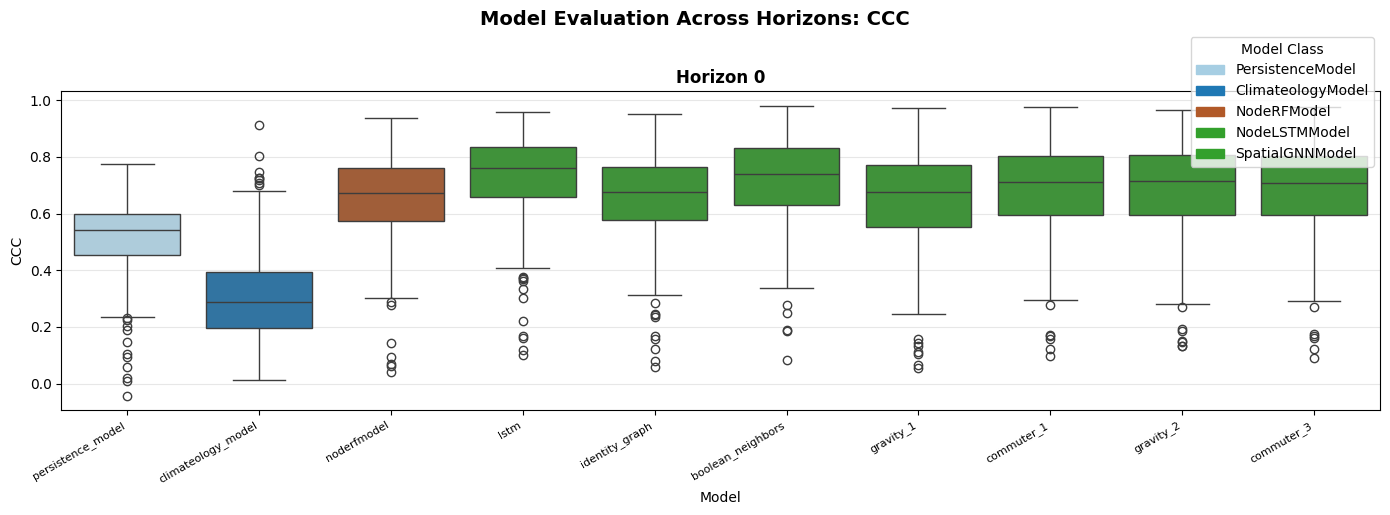

In [13]:
evaluation_space.plotter.plot_metric_horizons_separate('ccc', horizons= [0], plot_type='box')

/home/de-schrijvers/projects/germany_gnn/srcv2/evaluation/evaluationplotter.py:130: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center', fontsize=8)
/home/de-schrijvers/projects/germany_gnn/srcv2/evaluation/evaluationplotter.py:130: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center', fontsize=8)


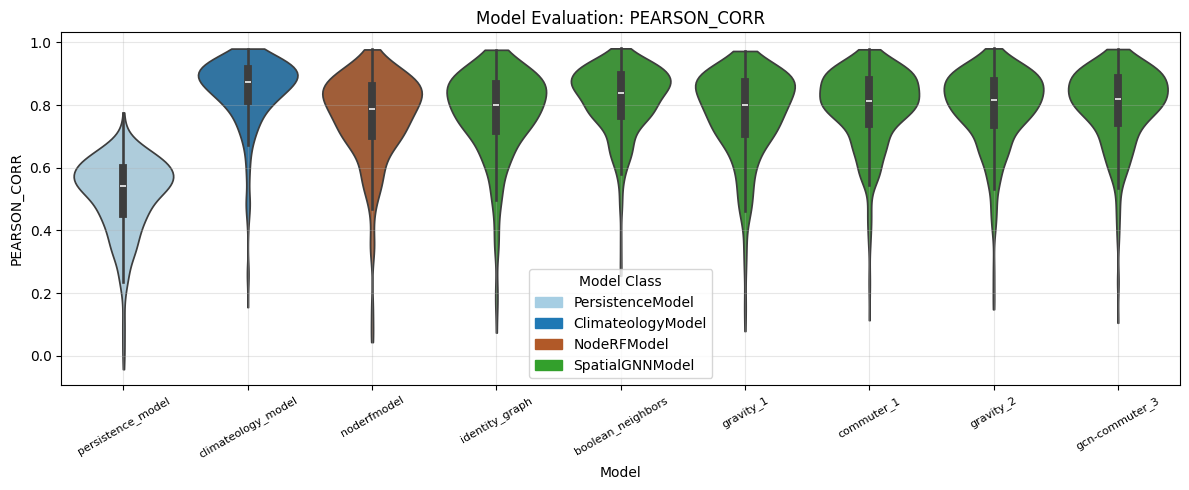

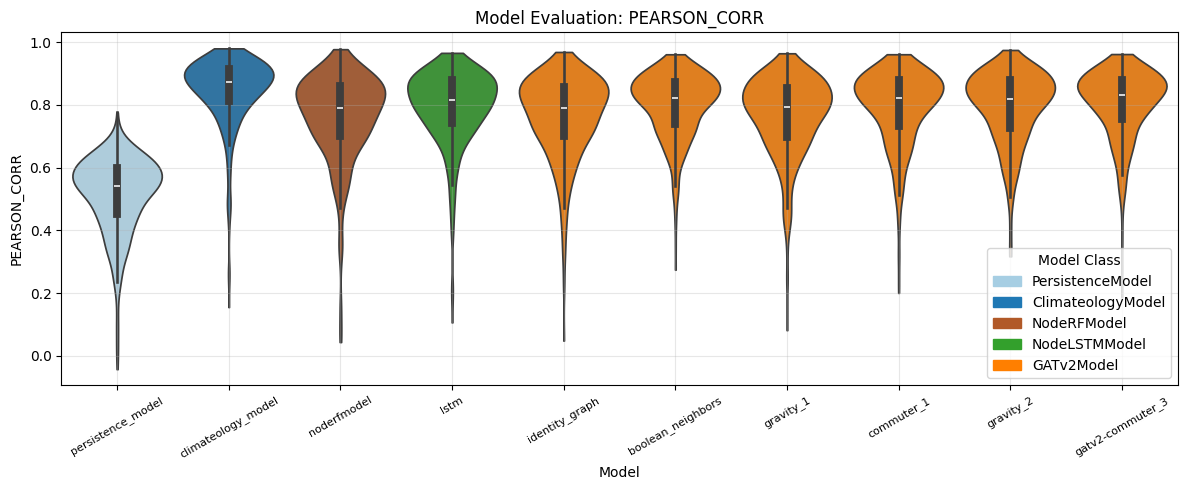

In [50]:
evaluation_space.plotter.plot_metric('pearson_corr','horizon_0')
evaluation_time.plotter.plot_metric('pearson_corr','horizon_0')

/home/de-schrijvers/projects/germany_gnn/srcv2/evaluation/evaluationplotter.py:290: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right', fontsize=8)


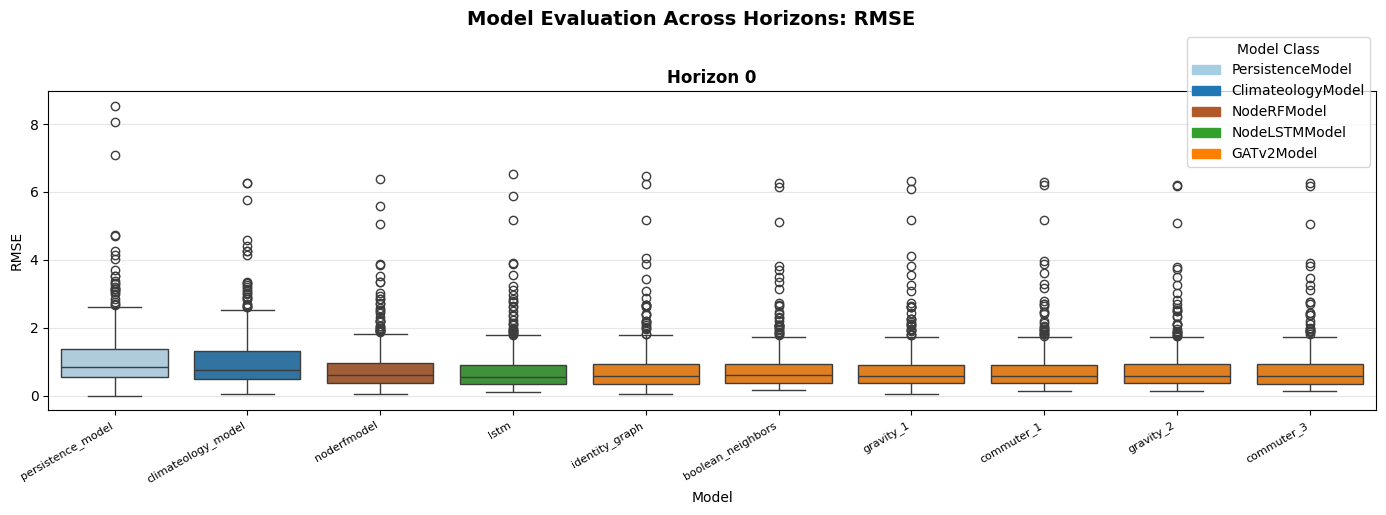

In [17]:
evaluation_time.plotter.plot_metric_horizons_separate('rmse', horizons= [0], plot_type='box')

computing metrics: 100%|████████████████████████████████████████████████████████████████████████| 6/6 [00:02<00:00,  2.08it/s]
/home/de-schrijvers/projects/germany_gnn/srcv2/evaluation/evaluationplotter.py:130: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center', fontsize=8)


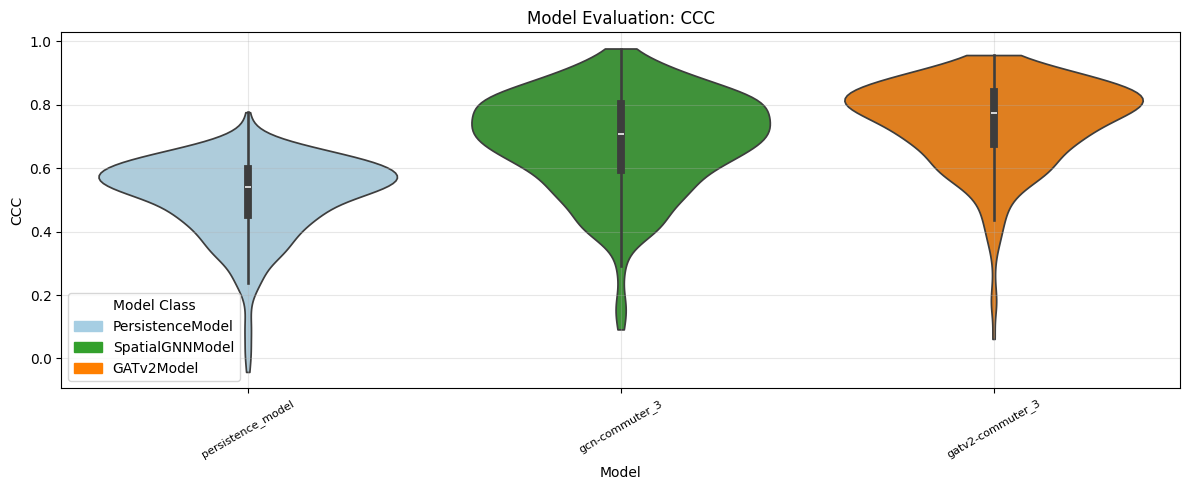

In [32]:
spatial_model6.name = 'GCN-commuter 3'
spatiotemporal_model6.name = 'GATv2-commuter 3'
timeseries_comparison = Evaluator([persistence,spatial_model6, spatiotemporal_model6])
timeseries_comparison.add_evaluation(0, 'test')
timeseries_comparison.plotter.plot_metric('ccc','horizon_0','test')

(<Figure size 1600x2200 with 4 Axes>,
 array([<Axes: title={'center': 'LK Ludwigsburg [node: 182]'}, ylabel='target'>,
        <Axes: title={'center': 'LK Rems-Murr-Kreis [node: 183]'}, ylabel='target'>,
        <Axes: title={'center': 'LK Main-Taunus-Kreis [node: 125]'}, ylabel='target'>,
        <Axes: title={'center': 'LK Augsburg [node: 309]'}, ylabel='target'>],
       dtype=object))

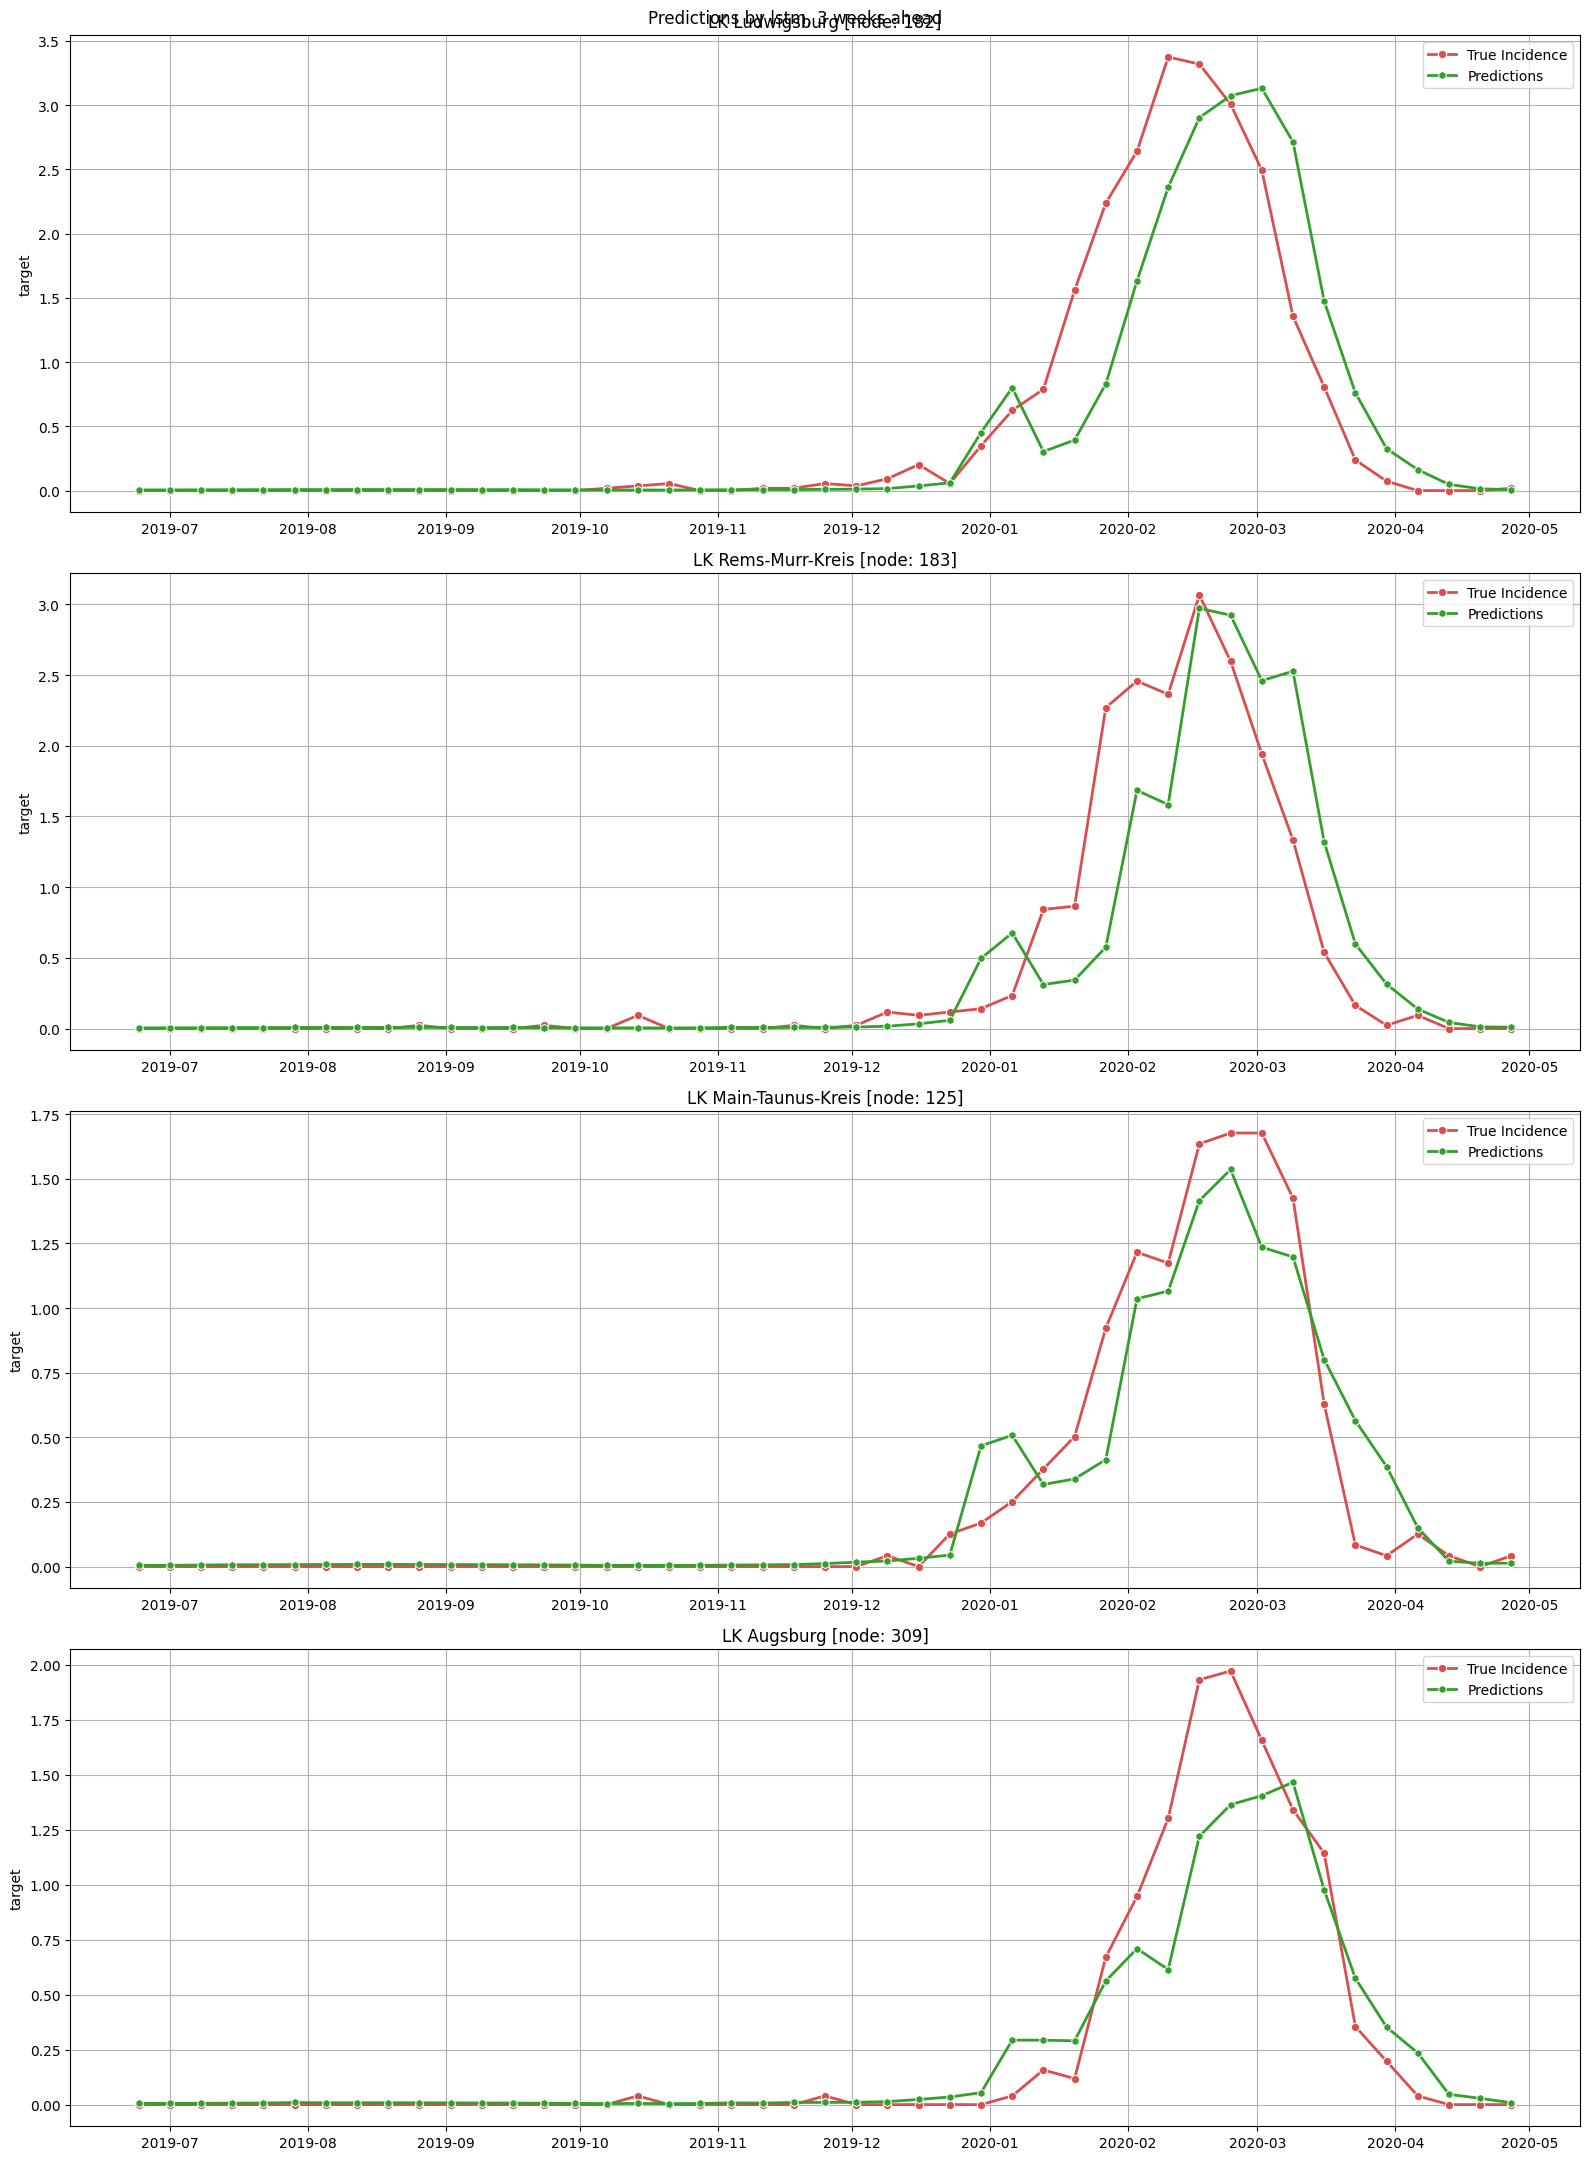

In [34]:
lstm.show_forecasts([182, 183, 125, 309])

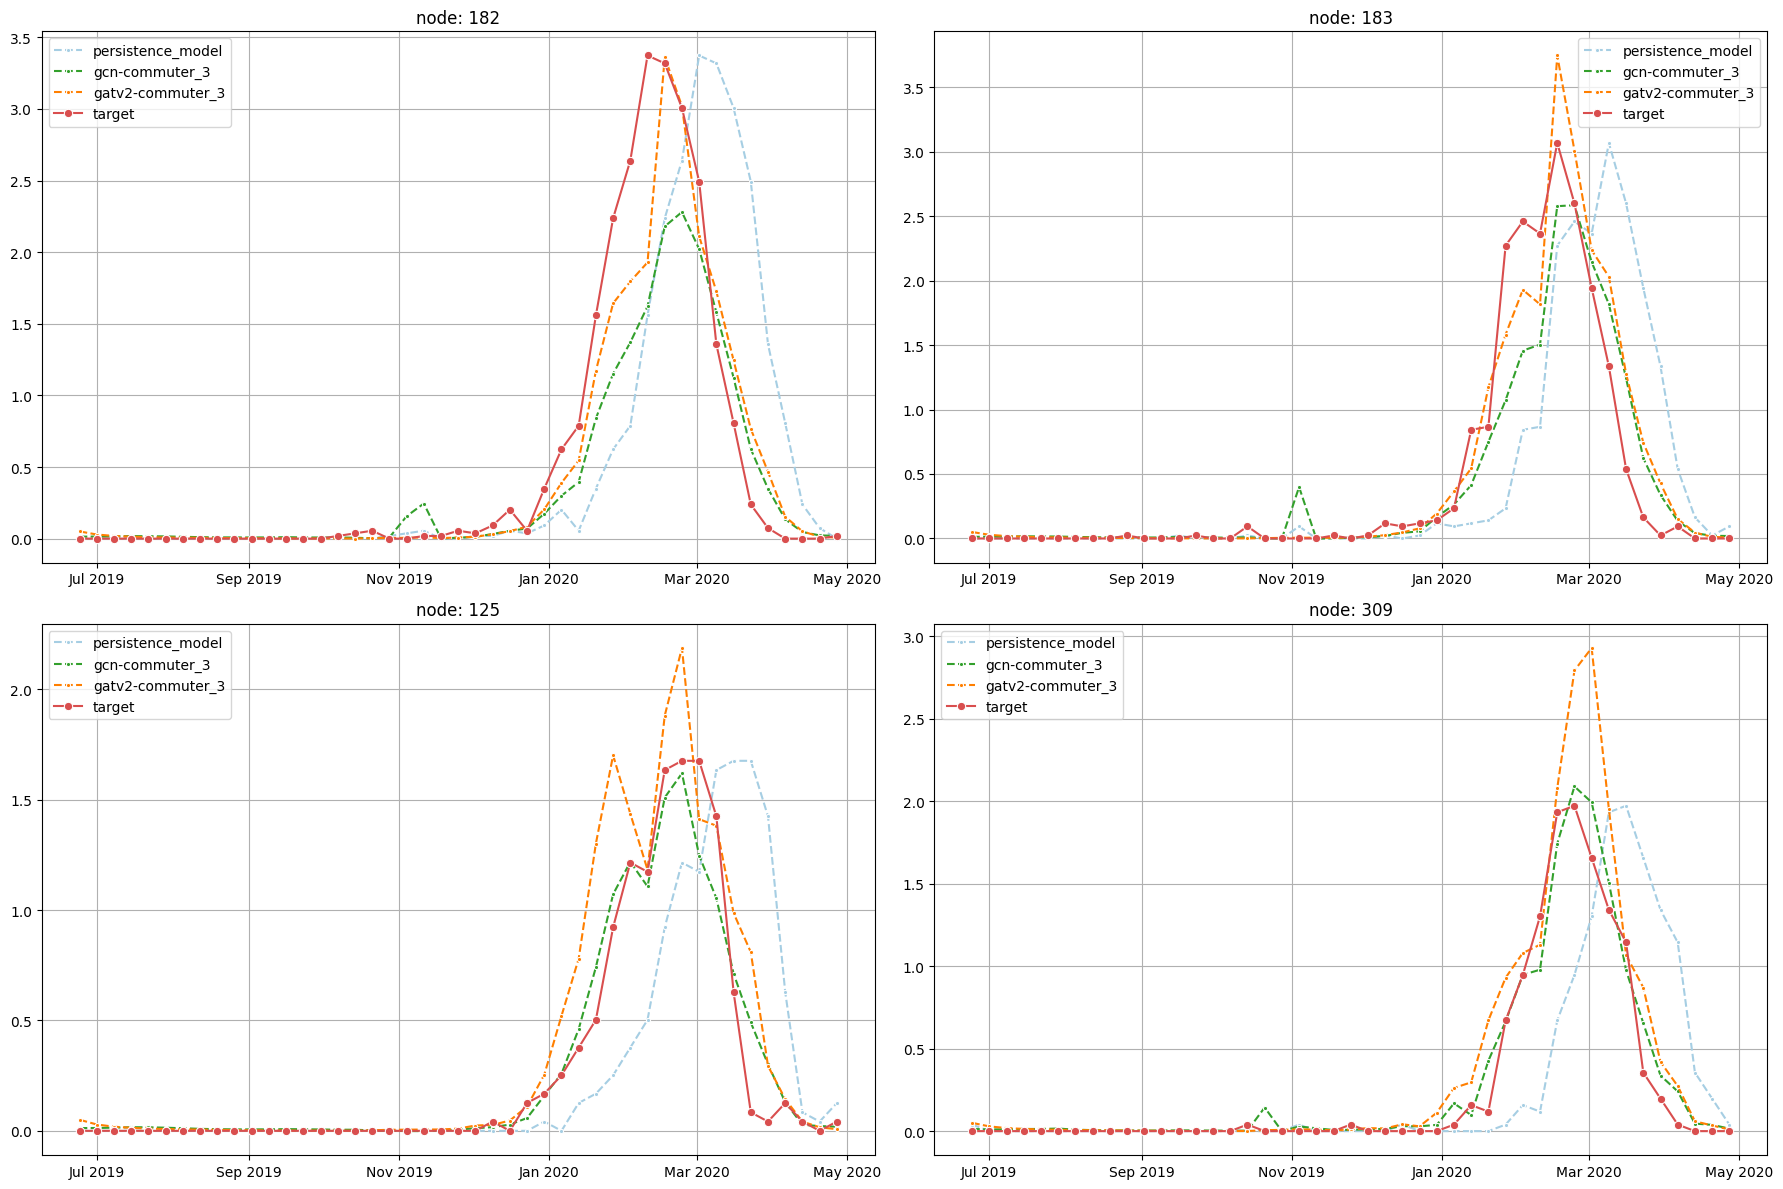

In [33]:
timeseries_comparison.plotter.plot_timeseries(nodes = [182, 183, 125, 309])